# Placement Prediction and Skill Gap Analysis Using Machine Learning

**Objective:** Predict a student's placement outcome and identify personalized skill gaps using ML.

This notebook walks through the full pipeline: data generation/loading, preprocessing, EDA,
model training & comparison, and skill-gap analysis.


In [1]:
import sys, os

# Make this notebook runnable whether launched from the project root or from
# inside the notebooks/ folder (e.g. via Jupyter's default working directory).
candidates = [os.getcwd(), os.path.join(os.getcwd(), "..")]
PROJECT_ROOT = next((os.path.abspath(c) for c in candidates if os.path.isdir(os.path.join(c, "src"))), os.getcwd())
os.chdir(PROJECT_ROOT)
sys.path.append(os.path.join(PROJECT_ROOT, "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
%matplotlib inline

print("Project root:", PROJECT_ROOT)


Project root: /home/claude/placement_project


## 1. Data Collection
We use a realistically simulated dataset of 1500 students (see `src/generate_dataset.py` for generation logic; in a real deployment, this would be a curated Kaggle/institutional placement dataset).

In [2]:
from preprocessing import load_data
df = load_data('data/placement_data.csv')
df.head()


,CGPA,Aptitude_Score,Technical_Skills,Communication_Skills,Projects_Count,Internships_Count,Certifications_Count,Backlogs,Branch,Placement_Status
0,7.65,76.7,25.7,47.6,1,2,6,0,MECH,1
1,7.08,56.7,44.5,41.7,1,0,2,0,CSE,0
2,7.78,52.7,52.6,38.2,3,0,0,0,CIVIL,0
3,8.57,64.9,94.0,68.2,5,2,3,0,ECE,1
4,6.99,62.4,70.0,58.8,2,2,1,0,IT,0


In [3]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CGPA                  1500 non-null   float64
 1   Aptitude_Score        1500 non-null   float64
 2   Technical_Skills      1500 non-null   float64
 3   Communication_Skills  1500 non-null   float64
 4   Projects_Count        1500 non-null   int64  
 5   Internships_Count     1500 non-null   int64  
 6   Certifications_Count  1500 non-null   int64  
 7   Backlogs              1500 non-null   int64  
 8   Branch                1500 non-null   str    
 9   Placement_Status      1500 non-null   int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 121.8 KB


,CGPA,Aptitude_Score,Technical_Skills,Communication_Skills,Projects_Count,Internships_Count,Certifications_Count,Backlogs,Placement_Status
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,7.245307,65.152733,59.167667,61.472533,2.498000,0.982000,1.877333,0.433333,0.508000
std,0.885236,14.548292,18.127759,14.932396,1.573843,0.982337,1.388370,0.666722,0.500103
min,5.000000,20.000000,10.000000,14.300000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.640000,55.500000,46.775000,51.800000,1.000000,0.000000,1.000000,0.000000,0.000000
50%,7.245000,64.950000,59.600000,61.600000,2.000000,1.000000,2.000000,0.000000,1.000000
75%,7.810000,75.100000,71.025000,71.700000,3.000000,2.000000,3.000000,1.000000,1.000000
max,10.000000,100.000000,100.000000,100.000000,8.000000,4.000000,6.000000,4.000000,1.000000


## 2. Data Preprocessing
Handle missing values, duplicates, and encode categorical features.

In [4]:
from preprocessing import encode_features
df_enc, branch_encoder = encode_features(df, fit=True)
df_enc.head()


,CGPA,Aptitude_Score,Technical_Skills,Communication_Skills,Projects_Count,Internships_Count,Certifications_Count,Backlogs,Branch,Placement_Status
0,7.65,76.7,25.7,47.6,1,2,6,0,5,1
1,7.08,56.7,44.5,41.7,1,0,2,0,1,0
2,7.78,52.7,52.6,38.2,3,0,0,0,0,0
3,8.57,64.9,94.0,68.2,5,2,3,0,2,1
4,6.99,62.4,70.0,58.8,2,2,1,0,4,0


## 3. Exploratory Data Analysis (EDA)

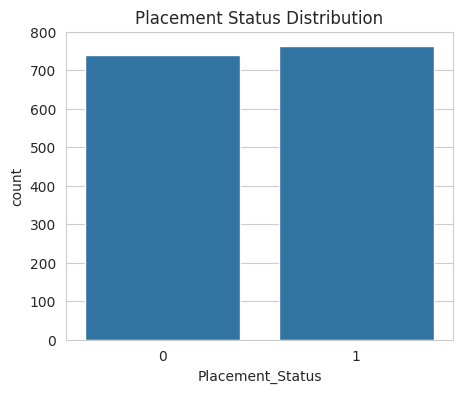

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x='Placement_Status', data=df)
plt.title('Placement Status Distribution')
plt.show()


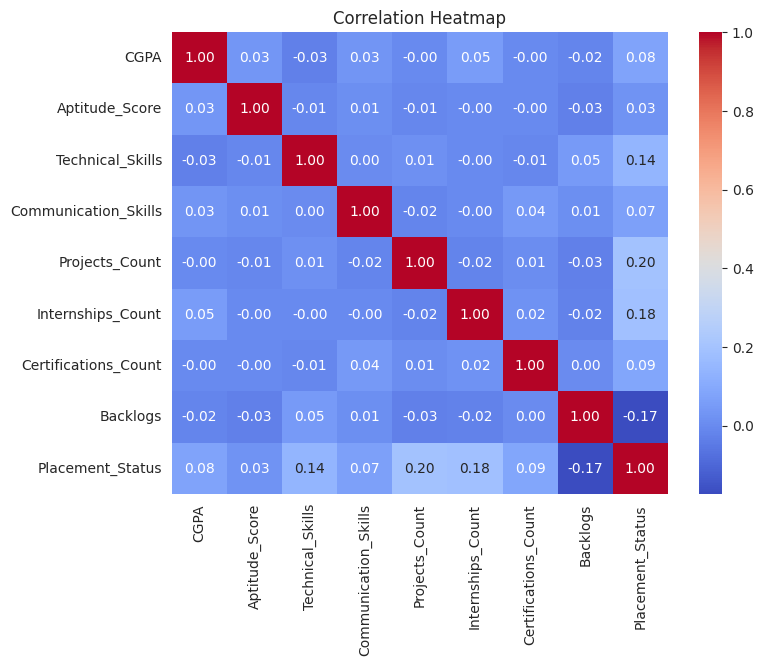

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


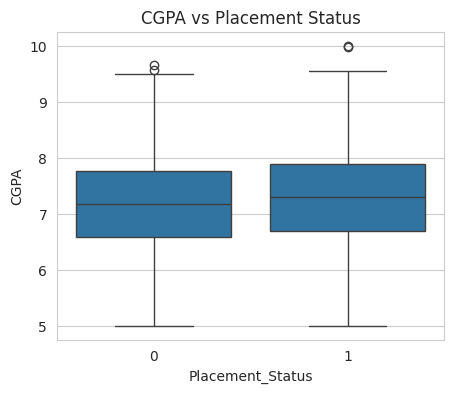

In [7]:
plt.figure(figsize=(5,4))
sns.boxplot(x='Placement_Status', y='CGPA', data=df)
plt.title('CGPA vs Placement Status')
plt.show()


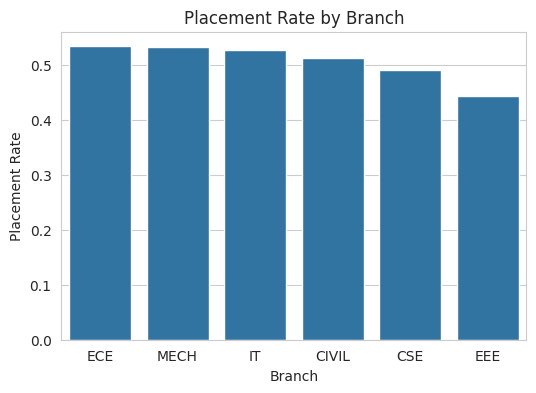

In [8]:
branch_rate = df.groupby('Branch')['Placement_Status'].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=branch_rate.index, y=branch_rate.values)
plt.ylabel('Placement Rate')
plt.title('Placement Rate by Branch')
plt.show()


## 4. Train/Test Split & Feature Scaling

In [9]:
from preprocessing import get_train_test_split, scale_features
X_train, X_test, y_train, y_test = get_train_test_split(df_enc)
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)
X_train.shape, X_test.shape


((1200, 9), (300, 9))

## 5. Model Training & Comparison
We train four classifiers: Logistic Regression, Decision Tree, Random Forest, and XGBoost, and compare them using Accuracy, Precision, Recall and F1-score.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.08, eval_metric='logloss', random_state=42),
}

results = []
trained = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1_Score': f1_score(y_test, y_pred),
    })
    trained[name] = model

results_df = pd.DataFrame(results).sort_values('F1_Score', ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.650000,0.655629,0.651316,0.653465
1,Decision Tree,0.616667,0.617834,0.638158,0.627832
3,XGBoost,0.606667,0.619718,0.578947,0.598639
2,Random Forest,0.596667,0.604027,0.592105,0.598007


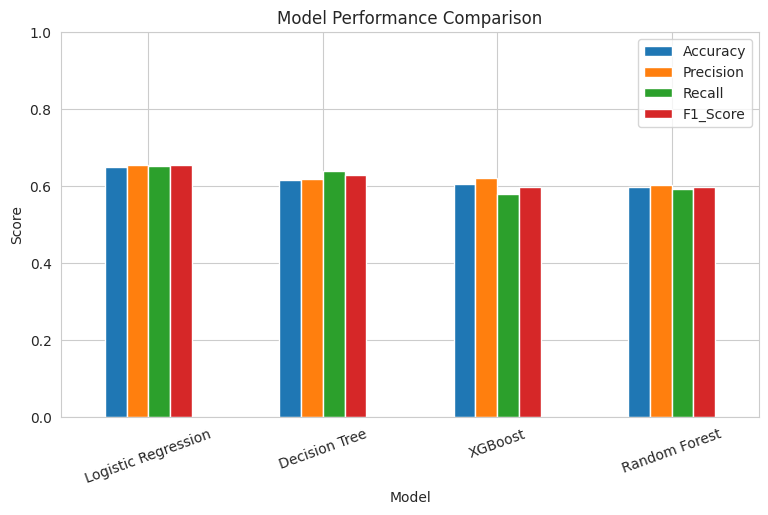

In [11]:
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1_Score']].plot(kind='bar', figsize=(9,5))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.show()


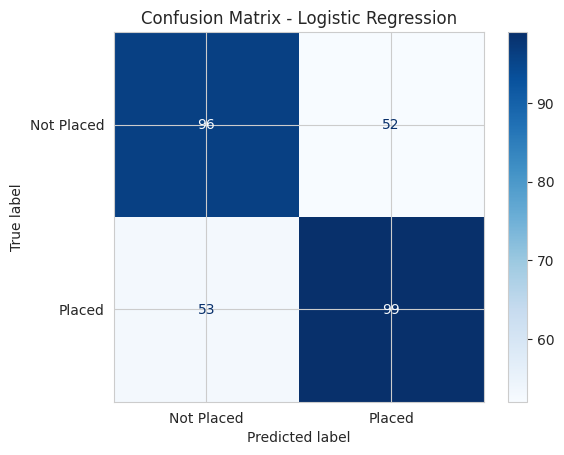

Best model: Logistic Regression


In [12]:
best_name = results_df.iloc[0]['Model']
best_model = trained[best_name]
y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Placed','Placed']).plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()
print(f'Best model: {best_name}')


### Feature Importance
For tree-based models, feature importance tells us which factors matter most for placement — this also feeds the skill-gap weighting.

In [13]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    importances.plot(kind='barh', figsize=(7,5), color='teal')
    plt.gca().invert_yaxis()
    plt.title(f'Feature Importance - {best_name}')
    plt.show()
else:
    print('Selected model does not expose feature_importances_ (e.g., Logistic Regression). '
          'Coefficients can be inspected instead via best_model.coef_')


Selected model does not expose feature_importances_ (e.g., Logistic Regression). Coefficients can be inspected instead via best_model.coef_


## 6. Skill Gap Analysis
For a given student, compare their skills against the average profile of *placed* students (within their branch), weighted by feature importance, to surface the highest-priority improvement areas.

In [14]:
import importlib
import skill_gap
importlib.reload(skill_gap)

sample_student = {
    'CGPA': 6.8,
    'Aptitude_Score': 55,
    'Technical_Skills': 45,
    'Communication_Skills': 50,
    'Projects_Count': 1,
    'Internships_Count': 0,
    'Certifications_Count': 1,
}

result = skill_gap.analyze_skill_gap(sample_student, branch='CSE')
result['gap_table']


,Feature,Your_Value,Benchmark_Value,Gap_Percent,Priority_Score
0,Internships_Count,0.0,1.25,100.0,14.286
1,Projects_Count,1.0,2.91,65.7,9.380
2,Certifications_Count,1.0,2.07,51.7,7.379
3,Technical_Skills,45.0,61.06,26.3,3.757
4,Communication_Skills,50.0,62.95,20.6,2.938
5,Aptitude_Score,55.0,65.47,16.0,2.284
6,CGPA,6.8,7.28,6.6,0.949


In [15]:
print('Top Recommendations:')
for r in result['recommendations']:
    print(f"- {r['Area']}: {r['Advice']}")


Top Recommendations:
- Internships_Count: Try to secure at least one internship — even a short one — to gain practical, resume-boosting experience.
- Projects_Count: Build 1-2 more solid, resume-worthy projects (ideally with real-world relevance and documentation).
- Certifications_Count: Complete relevant certifications (e.g., in your specialization or trending tech stacks) to validate your skills.


## 7. Conclusion

- Built and compared four ML classifiers for placement prediction.
- Identified the most influential factors driving placement outcomes.
- Implemented a Skill Gap Analysis module that benchmarks a student against successfully-placed peers and produces prioritized, actionable recommendations.
- The best model and preprocessing artifacts are saved to `models/` and served through a Streamlit dashboard (`app/app.py`) for an end-to-end interactive demo.

**Future improvements:** use a real placement dataset (e.g., from the institution or Kaggle) once available, add more granular skill categories (subject-wise scores), and explore explainability tools like SHAP for individual predictions.
